In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.optim as optim

# Поменяйте модель на `w2 * t_u ** 2 + w1 * t_u + b`.
## `А.` Какие части цикла обучения и не только необходимо поменять, чтобы учесть подобное новое определение?
## `Б.` Какие части безразличны к отключению модуля?
## `В.` Выше или ниже стал уровень потерь после обучения?
## `Г.` Стал ли фактический результат лучше или хуже?

## data

In [2]:
t_c = torch.tensor([0.5, 14.0, 15.0, 28.0, 11.0,
                    8.0, 3.0, -4.0, 6.0, 13.0, 21.0])
t_u = torch.tensor([35.7, 55.9, 58.2, 81.9, 56.3, 48.9,
                    33.9, 21.8, 48.4, 60.4, 68.4])

## model

In [3]:
def model(t_u, params):
    b = params[0]
    w1 = params[1]
    w2 = params[2]                                 # добавляем этот вес
    return w2 * (t_u * t_u) + w1 * t_u + b         # добавляем квадратичный член с новым весом

## loss

In [4]:
def loss_fn(t_p, t_c):
    squared_diffs = (t_p - t_c)**2
    return squared_diffs.mean()

## train-val split of data

In [5]:
n_samples = t_u.shape[0]
n_val = int(0.3 * n_samples)
n_val

3

In [6]:
shuffled_indices = torch.randperm(n_samples)

train_indices = shuffled_indices[:-n_val]
val_indices = shuffled_indices[-n_val:]

train_indices, val_indices

(tensor([ 3,  2,  0, 10,  5,  8,  7,  6]), tensor([4, 9, 1]))

In [7]:
train_t_u = t_u[train_indices]
train_t_c = t_c[train_indices]

val_t_u = t_u[val_indices]
val_t_c = t_c[val_indices]

## чтобы не разматывать портянку с одним кодом в двух контекстах, можно обернуть вычисление функции потерь в функцию с параметром, задающим градиентный контекст вычисления функции потерь:

In [8]:
def cv_calculate_loss_forward(t_u, t_c, params, is_train):
    with torch.set_grad_enabled(is_train):
        t_pred = model(t_u=t_u, params=params)
        loss = loss_fn(t_p=t_pred, t_c=t_c)
    return loss

In [9]:
def training_cv_grad_context_loop(n_epochs, optimizer, params, train_t_u, val_t_u, train_t_c, val_t_c):
    log = []
    for epoch in range(1, n_epochs + 1):
        train_loss = cv_calculate_loss_forward(t_u=train_t_u, t_c=train_t_c, params=params, is_train=True)
        val_loss = cv_calculate_loss_forward(t_u=val_t_u, t_c=val_t_c, params=params, is_train=False)
            
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()
        
        log.append(list(params.detach().numpy().copy()) + [float(train_loss.detach()), float(val_loss.detach())])
        
    return params.detach().numpy().copy(), np.array(log).copy()

## задаем стартовую точку и глобальные параметры, а также выбираем алгоритм поиска оптимума

In [10]:
params = torch.tensor([0.0, 1.0, 0.0], requires_grad=True)  # здесь добавляем стартовое значение веса квадратичного члена модели 
learning_rate = 0.001                                        # с SGD не сойдется - скорее всего даже из-за разно-масштабности градиента
optimizer = optim.Adam([params], lr=learning_rate)          # крутим глобальные, либо выбираем более устойчивый алгоритм обучения
nof_epochs = 30000

## проводим обучение

In [11]:
result, train_history = training_cv_grad_context_loop(
    n_epochs = nof_epochs, 
    optimizer = optimizer,
    params = params,
    train_t_u = train_t_u, 
    val_t_u = val_t_u, 
    train_t_c = train_t_c,
    val_t_c = val_t_c
)

result

array([-1.11055565e+01,  2.67502308e-01,  2.68322160e-03], dtype=float32)

## визуализируем обученную модель

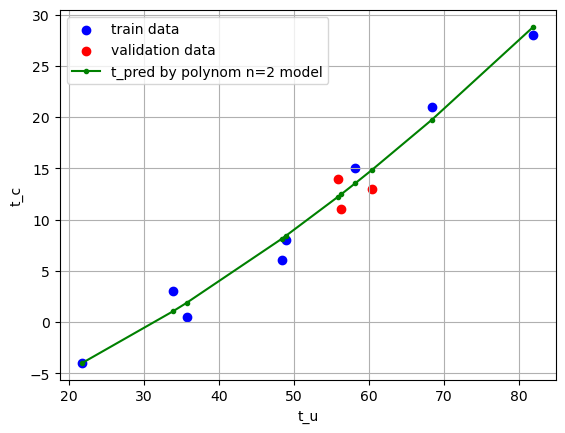

In [12]:
plt.scatter(train_t_u, train_t_c, color='blue', label='train data')
plt.scatter(val_t_u, val_t_c, color='red', label='validation data')
plt.plot(np.sort(t_u.numpy()), model(np.sort(t_u.numpy()), result), color='green', label='t_pred by polynom n=2 model', marker='.')

plt.xlabel('t_u')
plt.ylabel('t_c')
plt.grid()
plt.legend()
plt.show()

## визуализируем потери на обучающих и валидационных данных

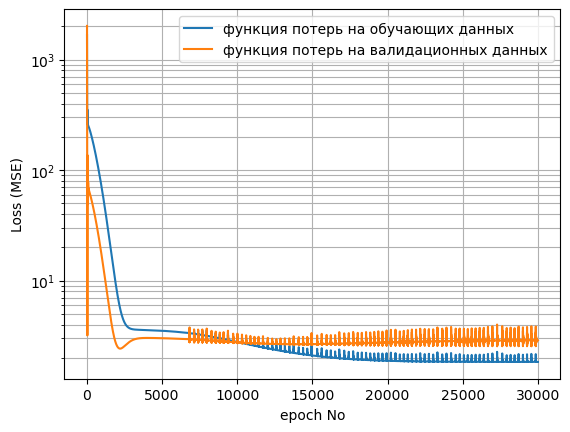

In [13]:
plt.plot(train_history[:,-2], label='функция потерь на обучающих данных')
plt.plot(train_history[:,-1], label='функция потерь на валидационных данных')
plt.yscale('log')

plt.xlabel('epoch No')
plt.ylabel('Loss (MSE)')
plt.grid(which='both')
plt.legend()
plt.show()

**периодические дерганья, видимо, заложенные в алгоритм мутационные скачки (для вывода процесса схождения из захвата локального минимума)**

**видно и переобучение, однако большого переобучения нет, так как число степеней свободы при квадратичной аппроксимации 8 точек все еще меньше чем число прецедентов обучения**

**картинка будет меняться при повторных прогонах всего кода, так как случайное разбиение 11 записей на 3 валидационных и 8 обучения вносит сильную стохастичность**

# Забавно другое - насколько неустойчивыми становятся коэффициенты квадратичной модели при валидационной выбросе данных

## немного поисследуем

In [17]:
nof_exp = 100

log = []
for i in range(nof_exp):
    idx = torch.randperm(n_samples)[:8]
    x = t_u[idx]
    y = t_c[idx]
    log.append( list(np.polyfit(x,y,1)) + list(np.polyfit(x,y,2)) )

np.array(log).std(axis=0)

array([2.82732372e-02, 1.58117326e+00, 1.83790954e-03, 1.92134465e-01,
       5.02776346e+00])